In [3]:
import os
import sys
import pandas as pd
import numpy as np

# 1. Dynamically fix path routing
# Add parent directory to path so python can see the 'src' folder
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import load_insurance_data, inspect_data_quality

# 2. Build absolute path straight to the data folder
data_path = os.path.join(project_root, "data", "insurance_data.csv")
print(f"Looking for dataset at absolute path:\n{data_path}\n")

# 3. Ingest historical data
df = load_insurance_data(data_path)

# 4. Inspect data completeness and schemas
quality_summary = inspect_data_quality(df)
print("--- DATA QUALITY METRICS ---")
print(quality_summary.head(15))

# 5. Compute structural portfolio risk benchmarks
overall_claims = df['TotalClaims'].sum()
overall_premium = df['TotalPremium'].sum()
portfolio_loss_ratio = (overall_claims / overall_premium) * 100 if overall_premium > 0 else 0

print("\n--- EXECUTIVE RISK SUMMARY ---")
print(f"Total Portfolio Premium: R {overall_premium:,.2f}")
print(f"Total Claims Incurred:   R {overall_claims:,.2f}")
print(f"Overall Loss Ratio:      {portfolio_loss_ratio:.2f}%")

Looking for dataset at absolute path:
c:\Users\user\insurance-risk-analytics\data\insurance_data.csv

--- DATA QUALITY METRICS ---
              Data Type  Missing Values  Missing %  Unique Values
CustomerID          str               0        0.0          10000
Age               int64               0        0.0             58
Gender              str               0        0.0              2
Province            str               0        0.0              5
VehicleType         str               0        0.0              4
AnnualIncome      int64               0        0.0           9545
RiskScore         int64               0        0.0             78
AnnualPremium     int64               0        0.0           2532
Deductible        int64               0        0.0              4
NCD               int64               0        0.0              6
PastClaims        int64               0        0.0              6
Claimed            bool               0        0.0              2
ClaimAmount

In [4]:
# Create a reusable function to isolate specific risk cohorts
def analyze_risk_segment(df, column_name):
    summary = df.groupby(column_name).agg(
        Total_Premium=('TotalPremium', 'sum'),
        Total_Claims=('TotalClaims', 'sum'),
        Policy_Count=('CustomerID', 'count'),
        Claim_Count=('Claimed', 'sum')
    ).reset_index()
    
    # Calculate operational risk metrics
    summary['Loss_Ratio_%'] = (summary['Total_Claims'] / summary['Total_Premium']) * 100
    summary['Claim_Frequency_%'] = (summary['Claim_Count'] / summary['Policy_Count']) * 100
    summary['Avg_Claim_Severity'] = summary['Total_Claims'] / summary['Claim_Count'].replace(0, 1)
    
    return summary.sort_values(by='Loss_Ratio_%', ascending=False)

# Execute risk analysis across core operational segments
for segment in ['Province', 'VehicleType', 'Gender']:
    print(f"\n================ RISKS BY {segment.upper()} ================")
    print(analyze_risk_segment(df, segment).to_string(index=False))


================ RISKS BY PROVINCE ================
   Province  Total_Premium  Total_Claims  Policy_Count  Claim_Count  Loss_Ratio_%  Claim_Frequency_%  Avg_Claim_Severity
     Somali        2984984     1826593.0          1184          207     61.192723          17.483108         8824.120773
     Oromia        6069663     3261061.0          2446          377     53.727217          15.412919         8650.029178
     Tigray        1990692     1047136.0           804          113     52.601608          14.054726         9266.690265
Addis Ababa        8907374     4653210.0          3567          559     52.239976          15.671433         8324.168157
     Amhara        4928566     2353885.0          1999          279     47.760038          13.956978         8436.863799

================ RISKS BY VEHICLETYPE ================
VehicleType  Total_Premium  Total_Claims  Policy_Count  Claim_Count  Loss_Ratio_%  Claim_Frequency_%  Avg_Claim_Severity
     Luxury        4236839     3569207.0    

C:\Users\user\AppData\Local\Temp\ipykernel_16028\3760483247.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prov_data, x='Province', y='Loss_Ratio_%', ax=axes[0], palette='Blues_r')
C:\Users\user\AppData\Local\Temp\ipykernel_16028\3760483247.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=veh_data, x='VehicleType', y='Loss_Ratio_%', ax=axes[1], palette='Oranges_r')


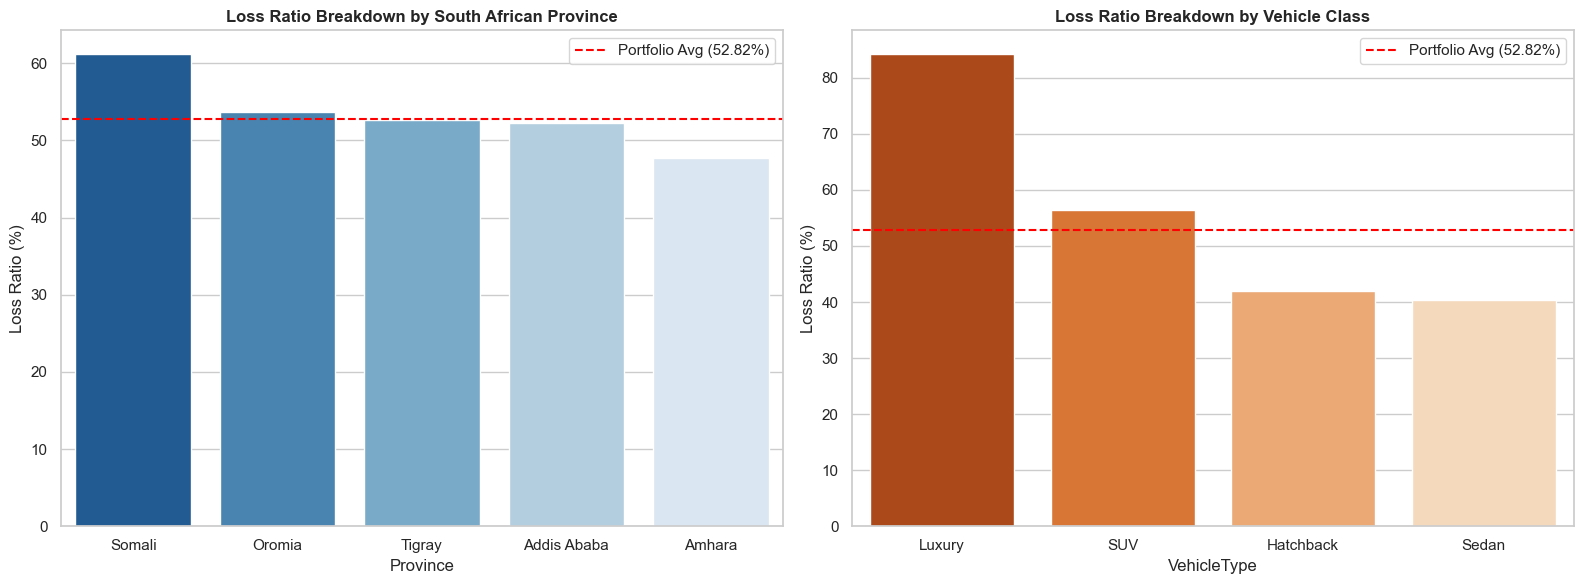

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Loss Ratios by Province
prov_data = analyze_risk_segment(df, 'Province')
sns.barplot(data=prov_data, x='Province', y='Loss_Ratio_%', ax=axes[0], palette='Blues_r')
axes[0].axhline(52.82, color='red', linestyle='--', label='Portfolio Avg (52.82%)')
axes[0].set_title('Loss Ratio Breakdown by South African Province', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss Ratio (%)')
axes[0].legend()

# Chart 2: Loss Ratios by Vehicle Type
veh_data = analyze_risk_segment(df, 'VehicleType')
sns.barplot(data=veh_data, x='VehicleType', y='Loss_Ratio_%', ax=axes[1], palette='Oranges_r')
axes[1].axhline(52.82, color='red', linestyle='--', label='Portfolio Avg (52.82%)')
axes[1].set_title('Loss Ratio Breakdown by Vehicle Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss Ratio (%)')
axes[1].legend()

plt.tight_layout()
plt.show()